<a href="https://colab.research.google.com/github/2403a54123-web/NLP/blob/main/2403A54123_NLP_Lab_Assignment_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# Data handling
import pandas as pd
import numpy as np

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
# Download stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

# Create dataset
data = {
"review":[
"I loved this movie","This film was amazing","Great acting and story",
"Fantastic movie","I really enjoyed the film",
"Worst movie ever","Terrible acting","Very boring film",
"I hated this movie","Waste of time",
"Brilliant storyline","Outstanding performance","Superb direction",
"Excellent movie","Loved the characters",
"Bad movie","Not good","Poor acting","Very dull film","Awful experience"
],

"sentiment":[
"positive","positive","positive","positive","positive",
"negative","negative","negative","negative","negative",
"positive","positive","positive","positive","positive",
"negative","negative","negative","negative","negative"
]
}

df = pd.DataFrame(data)

print(df.head())

                      review sentiment
0         I loved this movie  positive
1      This film was amazing  positive
2     Great acting and story  positive
3            Fantastic movie  positive
4  I really enjoyed the film  positive


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [10]:
def clean_text(text):

    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

df["clean_review"] = df["review"].apply(clean_text)

print("Sample Processed Text:")
print(df[["review","clean_review"]].head())

Sample Processed Text:
                      review         clean_review
0         I loved this movie          loved movie
1      This film was amazing         film amazing
2     Great acting and story   great acting story
3            Fantastic movie      fantastic movie
4  I really enjoyed the film  really enjoyed film


In [11]:
vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(df["clean_review"])
y = df["sentiment"]

print("Vocabulary Size:", len(vectorizer.vocabulary_))

Vocabulary Size: 31


In [12]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.3, random_state=42
)

# Train Logistic Regression
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [13]:
# Predictions
y_pred = model.predict(X_test)

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="positive")
recall = recall_score(y_test, y_pred, pos_label="positive")
f1 = f1_score(y_test, y_pred, pos_label="positive")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.3333333333333333
Precision: 0.3333333333333333
Recall: 1.0
F1 Score: 0.5

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         4
    positive       0.33      1.00      0.50         2

    accuracy                           0.33         6
   macro avg       0.17      0.50      0.25         6
weighted avg       0.11      0.33      0.17         6



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


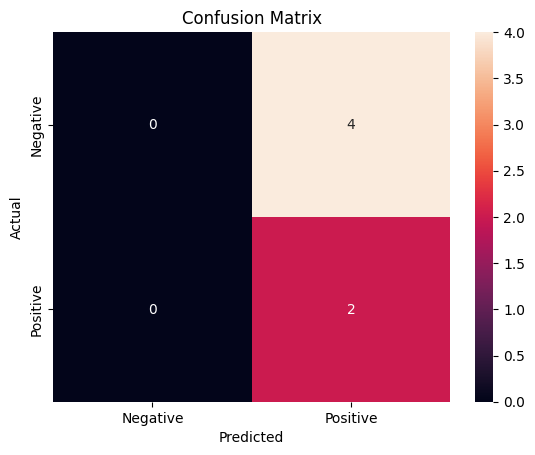

In [15]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d',
xticklabels=["Negative","Positive"],
yticklabels=["Negative","Positive"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()